# Experimento C — Outdoor vs. Indoor

## Preparación

In [4]:
%pip install pycolmap plotly open3d pandas tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Corrido en consola
# !sudo apt-get update -q
# !sudo apt-get install colmap -y -q

In [53]:
import os, shutil, time, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pycolmap
from pathlib import Path
from datetime import datetime

print("pycolmap:", pycolmap.__version__)


pycolmap: 4.0.4


### Paths e inicialización de carpetas

In [54]:
BASE_DIR    = Path('./expC')
LOGS_DIR    = BASE_DIR / 'logs'
RESULTS_DIR = BASE_DIR / 'results'
SPARSE_DIR  = BASE_DIR / 'sparse'
DB_DIR      = BASE_DIR / 'db'
DATA_DIR    = Path('./data')
EXP_D_DIR   = Path('./expD')

for d in [LOGS_DIR, RESULTS_DIR, SPARSE_DIR, DB_DIR, EXP_D_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SCENES     = ['garden', 'bonsai']
SCENE_TYPE = {'garden': 'outdoor', 'bicycle': 'outdoor',
              'bonsai': 'indoor',  'counter': 'indoor'}

CSV_PATH = RESULTS_DIR / 'df_expC.csv'

SCALE = 4

def get_image_path(scene):
    for scale in [f'images_{SCALE}', 'images']:
        p = DATA_DIR / scene / scale
        if p.exists():
            return p
    raise FileNotFoundError(f"No se encontró carpeta de imágenes para {scene}")


### Funciones varias

#### Para guardar los logs en un txt. Así se monitorea el avance sin ensuciar el cuaderno.

In [55]:
def execute_to_file(cmd, log_path, stage_name):
    """Ejecuta un comando y guarda stdout/stderr en el log."""
    print(f"  [>] {stage_name}...", end='', flush=True)
    t0 = time.time()
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(f"\n{'='*20}\nCOMANDO: {cmd}\n{'='*20}\n")
        proc = subprocess.Popen(cmd, shell=True, stdout=f,
                                stderr=subprocess.STDOUT, text=True)
        proc.wait()
    dt = time.time() - t0
    status = f"OK ({dt:.1f}s)" if proc.returncode == 0 else f"ERROR (ver {log_path.name})"
    print(f" {status}")
    return proc.returncode, dt

#### Para guardar los resultados en un mismo csv

In [56]:
def append_to_csv(metrics, csv_path):
    """Agrega o actualiza una fila en el CSV acumulativo."""
    df_new = pd.DataFrame([metrics])
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df = pd.concat([df, df_new], ignore_index=True)
        df = df.drop_duplicates(subset=['scene', 'config'], keep='last')
    else:
        df = df_new
    df.to_csv(csv_path, index=False)
    return df

#### Para contar componentes conexas

In [57]:
def count_components(output_path):
    """Cuenta el número de componentes conexas generadas por COLMAP."""
    if not output_path.exists():
        return 0
    return len([d for d in output_path.iterdir()
                if d.is_dir() and d.name.isdigit()])

#### Para correr un pipeline COLMAP

Algunas definiciones y consideraciones

- `reco_path` es la ruta al componente conexo de mayor tamaño (el modelo principal) generado por el proceso de Sparse Reconstruction. COLMAP los enumera empezando por el 0 según la cantidad de imágenes registradas.
- objeto `reco`: carga a memoria RAM toda la información de un modelo 3D generado por COLMAP. Permite conectar las imágenes, cámaras y puntos 3D, calcular métricas de forma fácil usando sus métodos integrados, entre otros.
  - `reco.num_reg_images()`: cuenta cuantas imágenes tiene el modelo 3D. Sirve para evaluar cuantas de las imágenes que se le dieron al modelo fueron usadas.
  - `reco.compute_num_observations()`: calcula la suma de cuantas veces un punto 3D fue vistos por una imagen.
  - `reco.points3D`: los puntos que COLMAP logró reconstruir.
    - `reco.points3D.values()[x].track`: lista de todas las fotos donde aparece ese punto.

Como los archivos son pesados y el tiempo de ejecución es alto, se calcula la mayor cantidad de métricas posibles por ejecución, lo que no significa que se vayan a usar:
- scene, scene_type, config: contexto del epxerimento
- model: cámara usada
- total_images, images_registered, registration_ratio: registro de imágenes
- points_3d: cantidad de puntos reconstruidos
- mean_reprojection_error: promedio de error de ubicación de punto en la imagen y de ubicación caclulada.
- total_observations: cantidad de observaciones de todos los puntos en las imágenes
- obs_per_point: promedio de cámaras que ven a un mismo punto 3D
- avg_track_length: promedio de fotos en las que aparece cada punto
- std_track_length: dispersión de la visibilidad de los puntos
- median_track_length: mediana de de la visibilidad de los puntos
- max_track_length: el número máximo de fotos que comparten un mismo punto 3D
- num_connected_components: número de sub-modelos independientes generados
- execution_time_sec: tiempo de ejecución del proceso, en segundos
- sparse_path: ubicación de los archivos .bin o .txt resultantes
- images_path: ubicación de las fotos originales
- timestamp: fecha y hora de ejecución del pipeline


In [58]:
def run_experiment(scene, conf):
    """
    Ejecuta el pipeline COLMAP completo para una escena y configuración.
    Guarda métricas en el CSV acumulativo y retorna el dict de métricas.
    """
    img_path  = get_image_path(scene)
    db_path   = DB_DIR      / f"{scene}_{conf['name']}.db"
    out_path  = SPARSE_DIR  / scene / conf['name']
    log_path  = LOGS_DIR    / f"log_{scene}_{conf['name']}.txt"

    out_path.mkdir(parents=True, exist_ok=True)
    
    if db_path.exists():  
        db_path.unlink()
    if log_path.exists(): 
        log_path.unlink()

    # Contar imágenes
    imgs_total = len(list(img_path.glob('*.jpg')) +
                     list(img_path.glob('*.JPG')) +
                     list(img_path.glob('*.png')))

    print(f"\n>>> {scene} | {conf['name']}  ({imgs_total} imágenes)")

    t_start = time.time()

    extract_cmd = (
        f"colmap feature_extractor "
        f"--database_path {db_path} "
        f"--image_path {img_path} "
        f"--ImageReader.single_camera 1 "
        f"--ImageReader.camera_model {conf['model']} "
        f"--SiftExtraction.use_gpu 1 "
        f"{conf.get('ext', '')}"
    )
    match_cmd = (
        f"colmap exhaustive_matcher "
        f"--database_path {db_path} "
        f"--SiftMatching.use_gpu 1 "
        f"{conf.get('match', '')}"
    )
    map_cmd = (
        f"colmap mapper "
        f"--database_path {db_path} "
        f"--image_path {img_path} "
        f"--output_path {out_path} "
        f"{conf.get('map', '')}"
    )

    execute_to_file(extract_cmd, log_path, "Extracción de features")
    execute_to_file(match_cmd,   log_path, "Matching")
    execute_to_file(map_cmd,     log_path, "Mapping (SfM)")

    t_end = time.time()

    reco_path    = out_path / "0"
    n_components = count_components(out_path)

    if reco_path.exists():
        reco  = pycolmap.Reconstruction(str(reco_path))
        imgs_reg = reco.num_reg_images()
        pts3d    = reco.num_points3D()
        n_obs    = reco.compute_num_observations()
        tracks   = (np.array([p.track.length() for p in reco.points3D.values()])
                    if pts3d > 0 else np.array([0]))

        metrics = {
            'scene'                     : scene,
            'scene_type'                : SCENE_TYPE[scene],
            'config'                    : conf['name'],
            'model'                     : conf['model'],
            'total_images'              : imgs_total,
            'images_registered'         : imgs_reg,
            'registration_ratio'        : imgs_reg / imgs_total if imgs_total > 0 else 0,
            'points_3d'                 : pts3d,
            'mean_reprojection_error'   : reco.compute_mean_reprojection_error(),
            'total_observations'        : n_obs,
            'obs_per_point'             : n_obs / pts3d if pts3d > 0 else 0,
            'avg_track_length'          : float(np.mean(tracks)),
            'std_track_length'          : float(np.std(tracks)),
            'median_track_length'       : float(np.median(tracks)),
            'max_track_length'          : float(np.max(tracks)),
            'num_connected_components'  : n_components,
            'execution_time_sec'        : t_end - t_start,
            'sparse_path'               : str(reco_path),
            'images_path'               : str(img_path),
            'timestamp'                 : datetime.now().isoformat(),
        }
    else:
        print(f"  [!] Sin reconstrucción generada para {conf['name']} en {scene}")
        metrics = {
            'scene'                     : scene,
            'scene_type'                : SCENE_TYPE[scene],
            'config'                    : conf['name'],
            'model'                     : conf['model'],
            'total_images'              : imgs_total,
            'images_registered'         : 0,
            'registration_ratio'        : 0.0,
            'points_3d'                 : 0,
            'mean_reprojection_error'   : None,
            'total_observations'        : 0,
            'obs_per_point'             : 0.0,
            'avg_track_length'          : 0.0,
            'std_track_length'          : 0.0,
            'median_track_length'       : 0.0,
            'max_track_length'          : 0.0,
            'num_connected_components'  : n_components,
            'execution_time_sec'        : t_end - t_start,
            'sparse_path'               : None,
            'images_path'               : str(img_path),
            'timestamp'                 : datetime.now().isoformat(),
        }

    append_to_csv(metrics, CSV_PATH)
    print(f"  Tiempo total: {t_end - t_start:.1f}s | "
          f"Registradas: {metrics['images_registered']} | "
          f"Puntos 3D: {metrics['points_3d']}")
    return metrics


## Verificación de imágenes disponibles

In [59]:
images_count = {}
for scene in SCENES:
    ip = get_image_path(scene)
    imgs = (list(ip.glob('*.jpg')) + list(ip.glob('*.JPG')) +
            list(ip.glob('*.png')))
    images_count[scene] = len(imgs)
    print(f"{scene:10s}: {len(imgs):4d} imágenes  ({ip})")


garden    :  185 imágenes  (data/garden/images)
bonsai    :  292 imágenes  (data/bonsai/images_4)


## Configuraciones

Todas corren sobre `garden` (outdoor) y `bonsai` (indoor).

### Resumen
Para analizar el comportamiento del pipeline en escenas outdoor e indoor, se ejecutaron siete configuraciones variando un parámetro a la vez respecto a una base común: modelo de cámara OPENCV, parámetros por defecto de extracción y matching, sin restricciones adicionales en el mapper. Las variaciones cubren cuatro categorías: modelo de cámara, densidad de features, umbral de matching y tamaño mínimo de modelo. Estos parámetros se eligieron porque afectan directamente las etapas del pipeline que más difieren entre escenas indoor y outdoor: la distorsión óptica, la densidad de correspondencias y la robustez del mapper (Schönberger & Frahm, 2016; COLMAP Contributors, 2026a). El objetivo no es encontrar la configuración óptima, sino identificar si la sensibilidad del pipeline a cada parámetro cambia según el tipo de escena.

### `Cam_OpenCV` y `Ext_HighFeatures`

Se ejecutan primero las configuraciones base y la de alta densidad de features. 

OPENCV se usa como modelo de cámara en ambas porque incorpora distorsión radial y tangencial, siendo más realista para cámaras convencionales; la literatura muestra que modelar correctamente la distorsión mejora la calibración y la estabilidad geométrica de la reconstrucción (Juarez-Salazar et al., 2020; COLMAP Contributors, 2026c). 

La comparación entre el default y 8.000 features permite ver si aumentar la densidad de descriptores mejora la reconstrucción o si el pipeline satura, lo que es especialmente relevante en exteriores con mayor variedad de textura (COLMAP Contributors, 2026a). Se intentó con valores mayores (10.000 y 12.000), pero superaban las capacidades de la máquina disponible.

In [60]:
CONFIGS_EXEC = [
    {
        "name"  : "Cam_OpenCV",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "",
        "map"   : "",
    },
]

results_exec = []
for scene in SCENES:
    for conf in CONFIGS_EXEC:
        if scene == "bonsai":
            r = run_experiment(scene, conf)
            results_exec.append(r)

df_exec = pd.DataFrame(results_exec)
print("\n=== Resultados ejecutados ===")
# Algunas de las métricas
cols_show = ['scene', 'config', 'images_registered', 'registration_ratio',
             'points_3d', 'mean_reprojection_error', 'avg_track_length',
             'num_connected_components', 'execution_time_sec']
print(df_exec[cols_show].to_string(index=False))



>>> bonsai | Cam_OpenCV  (292 imágenes)
  [>] Extracción de features... OK (73.5s)
  [>] Matching... OK (1852.1s)
  [>] Mapping (SfM)... OK (698.4s)
  Tiempo total: 2624.0s | Registradas: 292 | Puntos 3D: 96479

=== Resultados ejecutados ===
 scene     config  images_registered  registration_ratio  points_3d  mean_reprojection_error  avg_track_length  num_connected_components  execution_time_sec
bonsai Cam_OpenCV                292                 1.0      96479                 0.385766          9.749054                         1         2624.025022


### `Cam_Pinhole`

PINHOLE asume que la cámara no tiene distorsión de lente. Es una simplificación válida cuando la distorsión es moderada o las imágenes han sido previamente rectificadas, y COLMAP recomienda usar el modelo más simple que represente adecuadamente la cámara (COLMAP Contributors, 2026c). 

Se incluye para evaluar si modelar la distorsión es relevante, y si ese efecto difiere entre garden y bonsai: se espera que las escenas indoor sean más sensibles, dado que las cámaras suelen operar con focales más cortas y mayor distorsión (Juarez-Salazar et al., 2020; Ramalingam et al., 2006).

In [63]:
CONFIGS_PREV_CAMMODELS = [
    {
        "name"  : "Cam_Pinhole",
        "model" : "PINHOLE",
        "ext"   : "",
        "match" : "",
        "map"   : "",
    },
]

for scene in SCENES:
    for conf in CONFIGS_PREV_CAMMODELS:
        run_experiment(scene, conf)



>>> garden | Cam_Pinhole  (185 imágenes)
  [>] Extracción de features... OK (76.0s)
  [>] Matching... OK (3359.8s)
  [>] Mapping (SfM)... OK (497.4s)
  Tiempo total: 3933.4s | Registradas: 185 | Puntos 3D: 146010

>>> bonsai | Cam_Pinhole  (292 imágenes)
  [>] Extracción de features... OK (69.9s)
  [>] Matching... OK (1828.0s)
  [>] Mapping (SfM)... OK (1699.7s)
  Tiempo total: 3597.6s | Registradas: 292 | Puntos 3D: 60813


### `Ext_LowFeatures`

Reduce el número máximo de features a 4.000. Junto con Ext_HighFeatures, define el rango de variación del extractor. 

El objetivo es evaluar el límite inferior: cuántas features son suficientes para mantener una reconstrucción comparable. En interiores con superficies lisas o patrones repetidos, la calidad y distribución de las features importa más que la cantidad bruta, por lo que la degradación podría ser más pronunciada que en outdoor (Liu et al., 2024; COLMAP Contributors, 2026a).

In [64]:
CONFIGS_PREV_EXT = [
    {
        "name"  : "Ext_LowFeatures",
        "model" : "OPENCV",
        "ext"   : "--SiftExtraction.max_num_features 4000",
        "match" : "",
        "map"   : "",
    },
]

for scene in SCENES:
    for conf in CONFIGS_PREV_EXT:
        run_experiment(scene, conf)



>>> garden | Ext_LowFeatures  (185 imágenes)
  [>] Extracción de features... OK (76.0s)
  [>] Matching... OK (852.5s)
  [>] Mapping (SfM)... OK (382.3s)
  Tiempo total: 1310.8s | Registradas: 185 | Puntos 3D: 81606

>>> bonsai | Ext_LowFeatures  (292 imágenes)
  [>] Extracción de features... OK (66.2s)
  [>] Matching... OK (1533.5s)
  [>] Mapping (SfM)... OK (448.4s)
  Tiempo total: 2048.1s | Registradas: 292 | Puntos 3D: 94480


### `Match_Strict` y `Match_Loose`

El parámetro `max_error` controla el umbral geométrico bajo el cual un par de keypoints se acepta como match válido. Se evalúan simultáneamente el extremo estricto (1.5 px) y el permisivo (6.0 px). Un criterio estricto reduce falsos positivos pero puede perder correspondencias válidas en vistas con gran cambio de pose; uno permisivo amplía la cobertura a costa de incorporar más ruido (Wang et al., 2020; COLMAP Contributors, 2026a). Esto permite observar el trade-off entre cantidad y calidad de matches, y si ese trade-off se manifiesta de forma distinta en cada tipo de escena.

In [8]:
CONFIGS_PREV_MATCH = [
    {
        "name"  : "Match_Strict",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "--SiftMatching.max_error 1.5",
        "map"   : "",
    },
    {
        "name"  : "Match_Loose",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "--SiftMatching.max_error 6.0",
        "map"   : "",
    },
]

for scene in SCENES:
    for conf in CONFIGS_PREV_MATCH:
        run_experiment(scene, conf)



>>> garden | Match_Strict  (185 imágenes)
  [>] Extracción de features... OK (158.7s)
  [>] Matching... OK (3502.5s)
  [>] Mapping (SfM)... OK (1061.9s)
  Tiempo total: 4723.3s | Registradas: 185 | Puntos 3D: 130468

>>> garden | Match_Loose  (185 imágenes)
  [>] Extracción de features... OK (140.3s)
  [>] Matching... OK (3380.1s)
  [>] Mapping (SfM)... OK (546.6s)
  Tiempo total: 4067.0s | Registradas: 185 | Puntos 3D: 148290

>>> bonsai | Match_Strict  (292 imágenes)
  [>] Extracción de features... OK (66.2s)
  [>] Matching... OK (1710.6s)
  [>] Mapping (SfM)... OK (1145.2s)
  Tiempo total: 2922.0s | Registradas: 292 | Puntos 3D: 74536

>>> bonsai | Match_Loose  (292 imágenes)
  [>] Extracción de features... OK (70.4s)
  [>] Matching... OK (1723.4s)
  [>] Mapping (SfM)... OK (2144.2s)
  Tiempo total: 3938.0s | Registradas: 292 | Puntos 3D: 71672


### `Map_Robust`

Aumenta el tamaño mínimo de componente conexa que el mapper acepta como modelo válido, de 3 a 10 imágenes, descartando fragmentos con poco soporte geométrico (COLMAP Contributors, 2026b; Mwtarnowski, 2021). 

El objetivo es evaluar si esta restricción produce una reconstrucción más limpia o si, por el contrario, es demasiado agresiva para alguna de las escenas. 

**NOTA**: esta configuración colapsa completamente la reconstrucción en bonsai (10 imágenes registradas, 1.410 puntos), lo que se discute en detalle en la sección de resultados.

In [9]:
CONFIGS_PREV_MAP = [
    {
        "name"  : "Map_Robust",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "",
        "map"   : "--Mapper.min_model_size 10",
    },
]

for scene in SCENES:
    for conf in CONFIGS_PREV_MAP:
        run_experiment(scene, conf)



>>> garden | Map_Robust  (185 imágenes)
  [>] Extracción de features... OK (70.1s)
  [>] Matching... OK (3435.4s)
  [>] Mapping (SfM)... OK (536.0s)
  Tiempo total: 4041.6s | Registradas: 185 | Puntos 3D: 146085

>>> bonsai | Map_Robust  (292 imágenes)
  [>] Extracción de features... OK (67.7s)
  [>] Matching... OK (1687.5s)
  [>] Mapping (SfM)... OK (516.4s)
  Tiempo total: 2271.7s | Registradas: 10 | Puntos 3D: 1410


# Resultados

In [4]:
import pandas as pd
from IPython.display import display, Markdown

csv_path = f"{RESULTS_DIR}/results_expC.csv"

df = pd.read_csv(csv_path)
df_bonsai = df[df['scene'] == 'bonsai']
df_garden = df[df['scene'] == 'garden']

Se presenta un resumen por escena que destaca los valores extermos de las métricas principales. Este resumen permite identificar rápidamente qué configuración produce la mejor precisión geométrica, la mayor densidad de puntos y los tracks más robustos.

También se reportan los promedios por escena, lo que sirve como línea base para comparar el comportamiento general de garden vs. bonsai independientemente de la configuración.

Los promedios de bonsai se calculan excluyendo la configuración Map_Robust, que colapsa la reconstrucción a 10 imágenes y 1.410 puntos por efecto del parámetro `min_model_size=10`, no por una limitación de la escena. Incluirla distorsionaría la comparación. El caso se analiza en detalle más adelante.

In [7]:
def resumen_escena(df_escena, nombre, excluir_configs=None):
    if df_escena.empty:
        return ""
    
    if excluir_configs is not None:
        df_escena = df_escena[~df_escena['config'].isin(excluir_configs)]
        
    mejor_error = df_escena.loc[df_escena['mean_reprojection_error'].idxmin()]
    peor_error = df_escena.loc[df_escena['mean_reprojection_error'].idxmax()]
    mas_puntos = df_escena.loc[df_escena['points_3d'].idxmax()]
    mejor_track = df_escena.loc[df_escena['avg_track_length'].idxmax()]
    t_min_idx = df_escena['execution_time_sec'].idxmin()
    t_max_idx = df_escena['execution_time_sec'].idxmax()
    tiempo_min_conf = df_escena.loc[t_min_idx, 'config']
    tiempo_max_conf = df_escena.loc[t_max_idx, 'config']
    tiempo_min = df_escena.loc[t_min_idx, 'execution_time_sec']
    tiempo_max = df_escena.loc[t_max_idx, 'execution_time_sec']
    
    # Promedios
    prom_error = df_escena['mean_reprojection_error'].mean()
    prom_puntos = df_escena['points_3d'].mean()
    prom_track = df_escena['avg_track_length'].mean()
    
    nota_outlier = ""
    if excluir_configs:
        nota_outlier = f"\n>Promedios calculados excluyendo: {', '.join(excluir_configs)} (colapso del pipeline).\n"
        
    texto = f"""
### Escena: **{nombre}**

| Métrica | Valor | Configuración destacada |
|---------|-------|------------------------|
| Menor error de reproyección | {mejor_error['mean_reprojection_error']:.3f} px | {mejor_error['config']} |
| Mayor error de reproyección | {peor_error['mean_reprojection_error']:.3f} px | {peor_error['config']} |
| Más puntos 3D | {mas_puntos['points_3d']:,} | {mas_puntos['config']} |
| Track length más alto | {mejor_track['avg_track_length']:.2f} | {mejor_track['config']} |
| Tiempo mínimo | {tiempo_min:.0f} s | {tiempo_min_conf} |
| Tiempo máximo | {tiempo_max:.0f} s | {tiempo_max_conf} |

*Promedios (todas las configuraciones):*  
- Error: {prom_error:.3f} px  
- Puntos 3D: {prom_puntos:,.0f}  
- Track length: {prom_track:.2f}

{nota_outlier}
"""
    return texto

display(Markdown(resumen_escena(df_garden, "Garden (outdoor)")))
display(Markdown(resumen_escena(df_bonsai, "Bonsai (indoor)", excluir_configs=["Map_Robust"])))


### Escena: **Garden (outdoor)**

| Métrica | Valor | Configuración destacada |
|---------|-------|------------------------|
| Menor error de reproyección | 1.166 px | Match_Strict |
| Mayor error de reproyección | 1.326 px | Ext_LowFeatures |
| Más puntos 3D | 148,290 | Match_Loose |
| Track length más alto | 6.96 | Match_Strict |
| Tiempo mínimo | 1311 s | Ext_LowFeatures |
| Tiempo máximo | 4723 s | Match_Strict |

*Promedios (todas las configuraciones):*  
- Error: 1.239 px  
- Puntos 3D: 134,390  
- Track length: 6.64





### Escena: **Bonsai (indoor)**

| Métrica | Valor | Configuración destacada |
|---------|-------|------------------------|
| Menor error de reproyección | 0.372 px | Match_Strict |
| Mayor error de reproyección | 1.148 px | Match_Loose |
| Más puntos 3D | 100,162 | Cam_OpenCV |
| Track length más alto | 10.09 | Match_Strict |
| Tiempo mínimo | 2048 s | Ext_LowFeatures |
| Tiempo máximo | 3938 s | Match_Loose |

*Promedios (todas las configuraciones):*  
- Error: 0.627 px  
- Puntos 3D: 83,344  
- Track length: 8.78


>Promedios calculados excluyendo: Map_Robust (colapso del pipeline).



# (a)

La tabla presenta todas las configuraciones ordenadas por escena y cantidad de puntos 3D descendente. Esto permite comparar de un vistazo cómo varía cada métrica al cambiar los parámetros del pipeline. 

In [70]:
df['points_per_sec'] = df['points_3d'] / df['execution_time_sec']
cols = ['scene', 'scene_type', 'config',
    'total_images', 'images_registered', 'registration_ratio',
    'points_3d', 'mean_reprojection_error', 'avg_track_length',
    'num_connected_components', 'execution_time_sec']
tabla_a = df[cols].copy()
tabla_a = tabla_a.sort_values(['scene', 'points_3d'], ascending=[True, False])
tabla_a.columns = ['Escena', 'Tipo', 'Configuración',
    'Imgs total', 'Imgs registradas', 'Ratio registro',
    'Puntos 3D', 'Error reproy. (px)', 'Track length prom.',
    'Comp. conexas', 'Tiempo (s)']

display(tabla_a)

,Escena,Tipo,Configuración,Imgs total,Imgs registradas,Ratio registro,Puntos 3D,Error reproy. (px),Track length prom.,Comp. conexas,Tiempo (s)
2,bonsai,indoor,Cam_OpenCV,292,292,1.000000,100162,0.377986,9.484176,1,2416.904538
3,bonsai,indoor,Ext_HighFeatures,292,292,1.000000,98402,0.380774,9.655861,1,2415.084916
7,bonsai,indoor,Ext_LowFeatures,292,292,1.000000,94480,0.382625,9.004837,1,2048.094259
10,bonsai,indoor,Match_Strict,292,292,1.000000,74536,0.372138,10.093136,1,2922.014849
11,bonsai,indoor,Match_Loose,292,292,1.000000,71672,1.148019,6.874651,1,3938.032947
5,bonsai,indoor,Cam_Pinhole,292,292,1.000000,60813,1.101698,7.554059,1,3597.550094
13,bonsai,indoor,Map_Robust,292,10,0.034247,1410,0.688297,5.675177,2,2271.660633
9,garden,outdoor,Match_Loose,185,185,1.000000,148290,1.236637,6.585886,1,4067.003433
12,garden,outdoor,Map_Robust,185,185,1.000000,146085,1.235153,6.651997,1,4041.641545
0,garden,outdoor,Cam_OpenCV,185,185,1.000000,146084,1.235573,6.651961,1,4028.128087


Se observa que garden es considerablemente más robusto: todas las configuraciones registran las 185 imágenes y producen entre 81.000 y 148.000 puntos, con errores de reproyección relativamente similares (1.17–1.33 px). Bonsai, en cambio, muestra mayor sensibilidad: el rango de puntos va de 1.410 a 100.162, y el error varía entre 0.37 y 1.15 px según la configuración. Esto sugiere que las escenas indoor son más sensibles a los hiperparámetros del pipeline.

# (b)

Primero se analizarán los resultados a partir de distintas métricas, y luego se identificara(n) métrica(s) que discrimine(n) mejor el caso outdoor y mejor el caso indoor.

## Análisis mediante gráficos

In [32]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
import seaborn as sns

markers_map = {'garden': 'o', 'bonsai': 's'}

### Trade-off densidad vs. precisión

La relación entre la precisión geométrica (error de reproyección) y la robustez de los tracks (longitud media de track) revela cómo diferentes configuraciones del pipeline equilibran la cantidad de correspondencias y su calidad.

En este gráfico de dispersión, cada punto representa una combinación de escena y configuración. El eje horizontal muestra el error de reproyección promedio (menor es mejor), mientras que el eje vertical indica el track length promedio (mayor indica que los puntos 3D son vistos por más imágenes, lo que suele traducirse en mayor estabilidad). El tamaño del punto es proporcional al número de puntos 3D reconstruidos. Los colores distinguen las configuraciones, y los marcadores diferencian las escenas

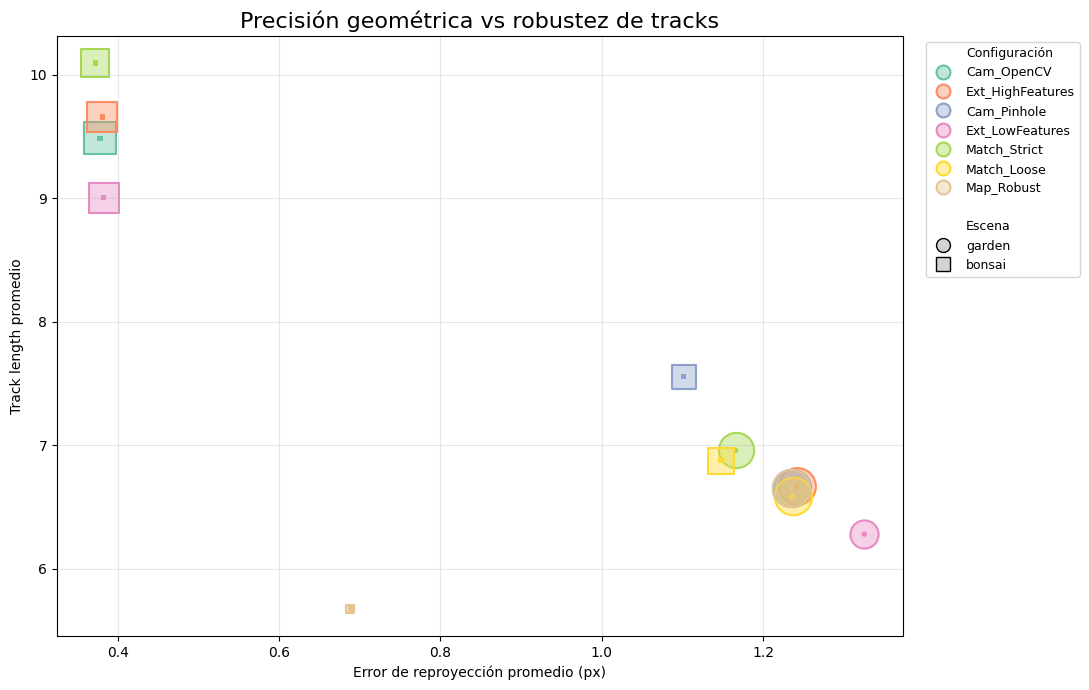

In [18]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

pts_min = df['points_3d'].min()
pts_max = df['points_3d'].max()

df_plot = df.copy()

df_plot['marker_size'] = (30 + (df_plot['points_3d'] - pts_min) / (pts_max - pts_min) * 700)

palette = dict(zip(df_plot['config'].unique(),sns.color_palette('Set2',n_colors=df_plot['config'].nunique())))

plt.figure(figsize=(11, 7))

for _, row in df_plot.iterrows():

    base_color = palette[row['config']]
    face_color = mcolors.to_rgba(base_color, alpha=0.4)

    plt.scatter(
        row['mean_reprojection_error'],
        row['avg_track_length'],
        s=row['marker_size'],
        marker=markers_map[row['scene']],
        facecolors=[face_color],
        edgecolors=[base_color],
        linewidths=1.5
    )
    
    plt.scatter(
        row['mean_reprojection_error'],
        row['avg_track_length'],
        s=15,
        marker=markers_map[row['scene']],
        facecolors=[base_color],
        edgecolors='none'
    )

legend_elements = []

legend_elements.append(Line2D([], [], linestyle='none', label='Configuración'))

for cfg, color in palette.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=cfg,
            markerfacecolor=mcolors.to_rgba(color, alpha=0.4),
            markeredgecolor=color,
            markersize=10,
            markeredgewidth=1.5
        )
    )

legend_elements.append(Line2D([], [], linestyle='none', label=''))

legend_elements.append(Line2D([], [], linestyle='none', label='Escena'))

for scene, marker in markers_map.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=marker,
            color='black',
            linestyle='None',
            label=scene,
            markerfacecolor='lightgray',
            markersize=10
        )
    )

plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    frameon=True
)

plt.title('Precisión geométrica vs robustez de tracks',fontsize=16)

plt.xlabel('Error de reproyección promedio (px)')
plt.ylabel('Track length promedio')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Se observan dos comportamientos claramente diferenciados:

- **Garden**: Todos los puntos correspondientes a esta escena tienen errores de reproyección muy similares y track lengths entre 6.3 y 7.0. A pesar de las variaciones en la densidad de features o en el modelo de cámara, la escena permanece estable. Aumentar los puntos 3D (tamaño del marcador) no penaliza significativamente el error ni mejora la longitud de track.
- **Bonsai**: Los puntos se dispersan mucho más. Las configuraciones que logran un menor error de reproyección (Match_Strict, Cam_OpenCV) también presentan los track lengths más altos (≈9.5–10.1), indicando que las correspondencias son más fiables y consistentes. En cambio, configuraciones como Match_Loose o Cam_Pinhole producen errores mayores (hasta 1.15 px) y tracks más cortos (≈6.9–7.6).

Un hallazgo adicional es que la configuración `Ext_LowFeatures` (4 000 features) en bonsai consigue un error intermedio (0.38 px) y un track length de 9.0, muy cercano a los valores de las mejores configuraciones para esta escena, pero con un tiempo de ejecución significativamente menor. Esto sugiere que, para escenas indoor, reducir la densidad de features puede ser una estrategia eficiente sin sacrificar calidad.

En resumen, el gráfico muestra que las escenas outdoor son estructuralmente más robustas frente a variaciones del pipeline, mientras que las indoor dependen mucho más de un ajuste cuidadoso de los parámetros de matching y calibración.

### Análisis del impacto de parámetros

Las siguientes figuras muestran cómo varían las principales métricas de reconstrucción al modificar distintos hiperparámetros del pipeline SfM. Se comparan simultáneamente las escenas para evaluar si ambos tipos de escena presentan el mismo nivel de sensibilidad frente a cambios en extracción de features, matching, modelo de cámara y restricciones del mapper.

La primera figura analiza métricas relacionadas con la calidad geométrica de la reconstrucción: cantidad de puntos 3D y error de reproyección promedio. La segunda se enfoca en la robustez estructural y el costo computacional del pipeline, utilizando el track length promedio y el tiempo total de ejecución.

El tiempo se reporta en minutos para facilitar la comparación entre configuraciones, ya que varias ejecuciones superan una hora de procesamiento.

#### Calidad geométrica: puntos 3D y error de reproyección

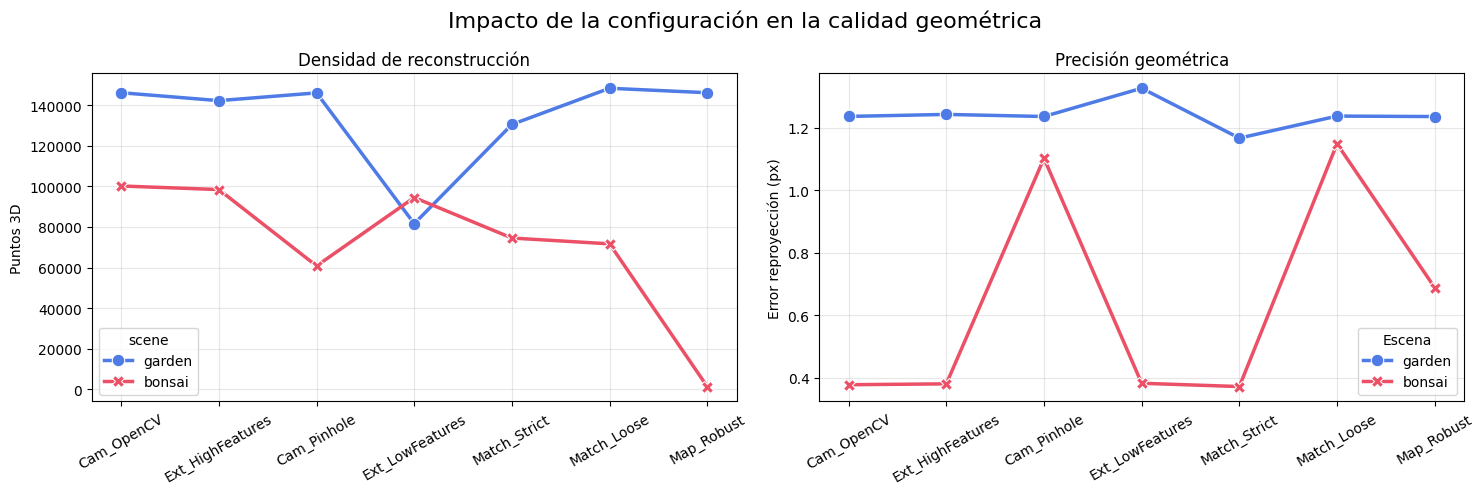

In [37]:
df_graf = df.copy()

metrics = ['points_3d','mean_reprojection_error','avg_track_length','execution_time_min']

titles = ['Cantidad de puntos 3D','Error de reproyección','Robustez de tracks','Tiempo de ejecución']

ylabels = ['Puntos 3D','Error (px)','Track length promedio','Tiempo (s)']

colors = {'garden': "#4e7be5",'bonsai': "#eb5067"}

order = ['Cam_OpenCV','Cam_Pinhole','Ext_LowFeatures','Ext_HighFeatures','Match_Strict','Match_Loose','Map_Robust']

df_plot['execution_time_min'] = (df_plot['execution_time_sec'] / 60)

f_plot = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.lineplot(
    data=df_plot,
    x='config',
    y='points_3d',
    hue='scene',
    style='scene',
    palette=colors,
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    ax=axes[0]
)

axes[0].set_title('Densidad de reconstrucción')
axes[0].set_ylabel('Puntos 3D')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=df_plot,
    x='config',
    y='mean_reprojection_error',
    hue='scene',
    style='scene',
    palette=colors,
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    ax=axes[1]
)

axes[1].set_title('Precisión geométrica')
axes[1].set_ylabel('Error reproyección (px)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

axes[1].legend(title='Escena')

plt.suptitle('Impacto de la configuración en la calidad geométrica',fontsize=16)

plt.tight_layout()
plt.show()

La calidad geométrica de garden se mantiene relativamente estable frente a la mayoría de las configuraciones evaluadas. Exceptuando `Ext_LowFeatures`, todas las configuraciones producen densidades de reconstrucción similares, con diferencias pequeñas en el error de reproyección. Esto sugiere que la escena outdoor posee suficiente redundancia visual y cobertura espacial para que modificaciones moderadas en extracción y matching no degradaen significativamente la reconstrucción.

En contraste, bonsai presenta una sensibilidad mucho mayor. Configuraciones como `Cam_Pinhole` y `Match_Loose` aumentan de gran manera el error de reproyección y reducen la cantidad de puntos reconstruidos, mostrando que la escena indoor depende más críticamente de un modelado geométrico preciso y de correspondencias robustas.

#### Robustez de tracks y costo computacional

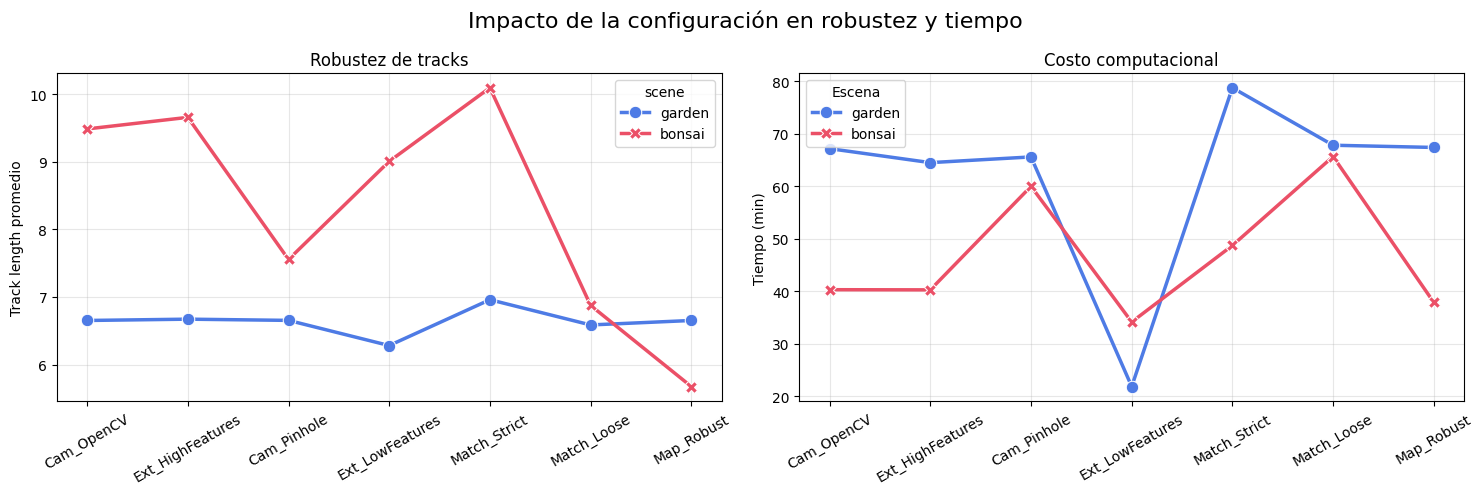

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.lineplot(
    data=df_plot,
    x='config',
    y='avg_track_length',
    hue='scene',
    style='scene',
    palette=colors,
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    ax=axes[0]
)

axes[0].set_title('Robustez de tracks')
axes[0].set_ylabel('Track length promedio')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=df_plot,
    x='config',
    y='execution_time_min',
    hue='scene',
    style='scene',
    palette=colors,
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    ax=axes[1]
)

axes[1].set_title('Costo computacional')
axes[1].set_ylabel('Tiempo (min)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

axes[1].legend(title='Escena')

plt.suptitle('Impacto de la configuración en robustez y tiempo',fontsize=16)

plt.tight_layout()
plt.show()

Las métricas de robustez muestran diferencias estructurales importantes entre ambas escenas. Bonsai alcanza en su mayoría, valores de track length más altos que garden, indicando que los puntos 3D son observados por más imágenes y poseen mayor soporte geométrico. Sin embargo, esta robustez también resulta más sensible a configuraciones agresivas de matching y calibración.

En términos computacionales, configuraciones más estrictas, como `Match_Strict`, aumentan considerablemente el tiempo total de ejecución debido al mayor costo de validación geométrica, mientras que `Ext_LowFeatures` reduce drásticamente el tiempo al disminuir la cantidad de descriptores procesados.

Finalmente, `Map_Robust` evidencia el comportamiento más extremo: mientras garden permanece prácticamente inalterado, bonsai colapsa casi por completo. Esto confirma que las escenas indoor complejas pueden ser altamente sensibles a restricciones geométricas fuertes en el mapper, incluso cuando el resto del pipeline permanece estable.

### Métricas normalizadas por cantidad de imágenes

Las métricas analizadas anteriormente corresponden a valores absolutos de cada reconstrucción. Sin embargo, las escenas no contienen la misma cantidad de imágenes: bonsai posee 292 imágenes frente a las 185 de garden, es decir, un 58% más. Esto puede influir especialmente en métricas como cantidad de puntos 3D, número de observaciones y tiempo total de ejecución.

Para realizar una comparación más justa entre escenas, se normalizaron ciertas métricas respecto al número total de imágenes procesadas. De esta forma, es posible evaluar la eficiencia relativa de cada configuración y distinguir si las diferencias observadas provienen realmente de la estructura de la escena o simplemente del tamaño del dataset.

En particular, se analizaron:

- Puntos 3D por imagen, como medida de densidad relativa de reconstrucción.
- Observaciones por imagen, como indicador de redundancia geométrica.
- Tiempo por imagen, para comparar el costo computacional relativo de cada configuración.

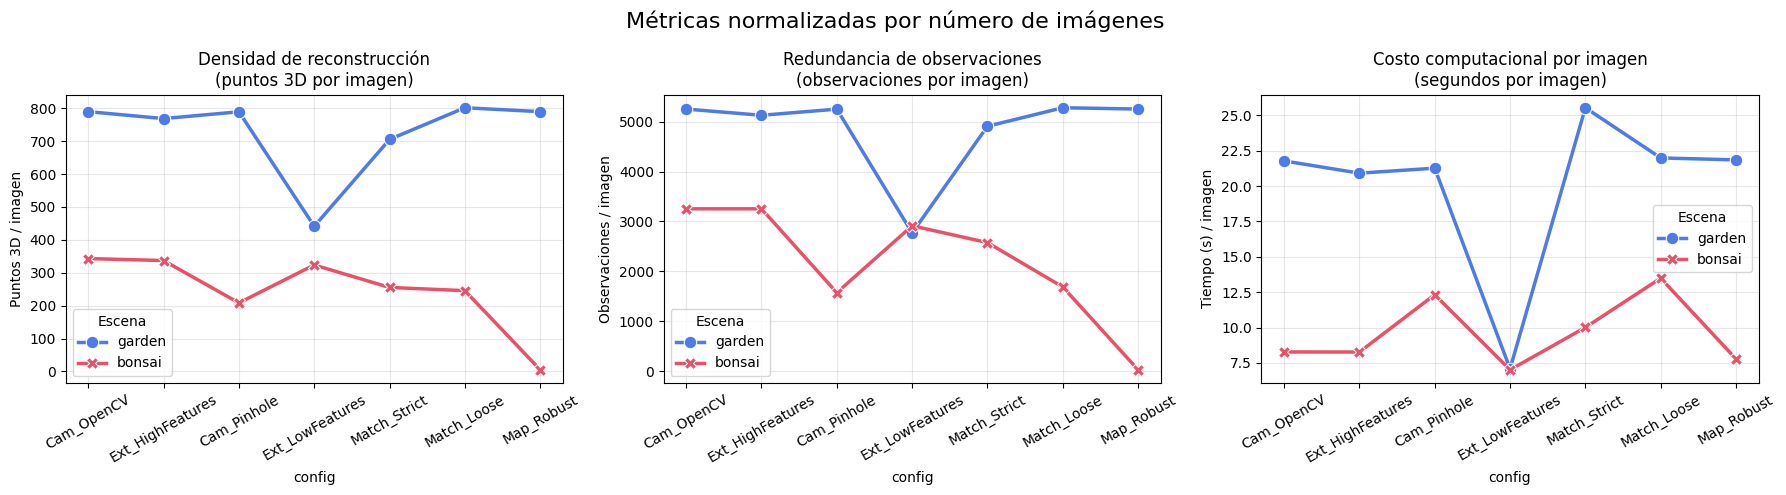

In [ ]:
df_plot['points_per_image'] = df_plot['points_3d'] / df_plot['total_images']
df_plot['observations_per_image'] = df_plot['total_observations'] / df_plot['total_images']
df_plot['time_per_image'] = df_plot['execution_time_sec'] / df_plot['total_images']


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=df_plot, x='config', y='points_per_image', hue='scene',
             style='scene', palette=colors, markers=True, dashes=False,
             linewidth=2.5, markersize=9, sort=False, ax=axes[0])
axes[0].set_title('Densidad de reconstrucción\n(puntos 3D por imagen)')
axes[0].set_ylabel('Puntos 3D / imagen')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(alpha=0.3)
axes[0].legend(title='Escena')

sns.lineplot(data=df_plot, x='config', y='observations_per_image', hue='scene',
             style='scene', palette=colors, markers=True, dashes=False,
             linewidth=2.5, markersize=9, sort=False, ax=axes[1])
axes[1].set_title('Redundancia de observaciones\n(observaciones por imagen)')
axes[1].set_ylabel('Observaciones / imagen')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)
axes[1].legend(title='Escena')

sns.lineplot(data=df_plot, x='config', y='time_per_image', hue='scene',
             style='scene', palette=colors, markers=True, dashes=False,
             linewidth=2.5, markersize=9, sort=False, ax=axes[2])
axes[2].set_title('Costo computacional por imagen\n(segundos por imagen)')
axes[2].set_ylabel('Tiempo (s) / imagen')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(alpha=0.3)
axes[2].legend(title='Escena')

plt.suptitle('Métricas normalizadas por número de imágenes', fontsize=16)
plt.tight_layout()
plt.show()

La normalización confirma que las diferencias entre escenas no son un artefacto del tamaño del dataset. Garden mantiene mayor densidad relativa (700–800 puntos/imagen vs. 240–340 en bonsai) y mayor redundancia de observaciones, lo que refleja una escena exteriormente más rica en textura y cobertura espacial. En costo computacional, garden resulta más caro por imagen precisamente por esa mayor densidad de correspondencias. El colapso de Map_Robust en bonsai es aún más evidente en métricas normalizadas, confirmando que la restricción del mapper es demasiado agresiva para la estructura de esa escena.

## Métricas discriminantes

A partir de los gráficos anteriores, es posible identificar métricas que permiten distinguir de forma clara el comportamiento de escenas outdoor e indoor bajo distintas configuraciones del pipeline SfM.

### Métrica que mejor discrimina el caso outdoor: densidad de reconstrucción por imagen
La métrica que mejor caracteriza el comportamiento outdoor es la cantidad de puntos 3D por imagen (`points_per_image`).

En todas las configuraciones estables, garden mantiene valores consistentemente altos, cercanos a 700–800 puntos 3D por imagen, muy por encima de bonsai, que normalmente se mantiene entre 240 y 340. Esta diferencia permanece incluso después de normalizar por la cantidad de imágenes, por lo que no depende simplemente del tamaño del dataset.

Además, esta métrica presenta muy poca variación en garden frente a cambios de configuración. Tanto en los gráficos absolutos como en los normalizados, las curvas outdoor permanecen relativamente planas, indicando que la escena exterior posee una geometría suficientemente rica y distribuida para reconstruirse de manera estable aun cuando cambian parámetros de extracción, matching o calibración.

Esto se relaciona directamente con las características típicas de escenas outdoor:

- Mayor cobertura espacial.
- Más textura distribuida.
- Mayor paralaje entre vistas.
- Más correspondencias válidas entre imágenes.

Por esta razón, la densidad de reconstrucción relativa discrimina muy bien el comportamiento outdoor frente al indoor.

### Métrica que mejor discrimina el caso indoor: track length promedio
La métrica que mejor discrimina el comportamiento indoor es el `avg_track_length`.

En los gráficos de trade-off y robustez, bonsai alcanza track lengths más altos que garden bajo configuraciones bien ajustadas.

Además, esta métrica refleja claramente la sensibilidad estructural de la escena indoor frente a cambios del pipeline. Configuraciones como `Cam_OpenCV` y `Match_Strict` mantienen tracks largos y consistentes, mientras que `Match_Loose`, `Cam_Pinhole` y especialmente `Map_Robust` reducen significativamente la longitud promedio de track.

Esto indica que, en escenas indoor, la calidad de las correspondencias multivista depende fuertemente de la calibración y del matching geométrico. Cuando las configuraciones son adecuadas, los puntos 3D son observados por muchas imágenes, generando tracks largos y robustos; cuando no lo son, la conectividad geométrica colapsa rápidamente.

Por ello, el `avg_track_length` representa mejor la naturaleza estructural y la sensibilidad geométrica de las escenas indoor.

# (c)

Las diferencias observadas entre las escenas outdoor (`garden`) e indoor (`bonsai`) no solo dependen de los hiperparámetros del pipeline, sino también de propiedades intrínsecas de cada escena.

Como se observó en las secciones anteriores, `garden` mantiene reconstrucciones relativamente estables frente a cambios de configuración, mientras que `bonsai` presenta una sensibilidad considerablemente mayor. Estas diferencias pueden explicarse por factores como:

- distribución espacial de features,
- textura presente en la escena,
- baseline entre cámaras,
- profundidad de campo,
- iluminación,
- presencia de patrones repetitivos,
- nivel de redundancia visual.

A continuación se analizan estos factores utilizando métricas estructurales y visualizaciones de correspondencias extraídas directamente de las reconstrucciones.

## Robustez geométrica y distribución de tracks

La distribución de track lengths permite analizar cuántas imágenes observan cada punto 3D reconstruido. Tracks más largos indican mayor redundancia geométrica y correspondencias más consistentes entre vistas.

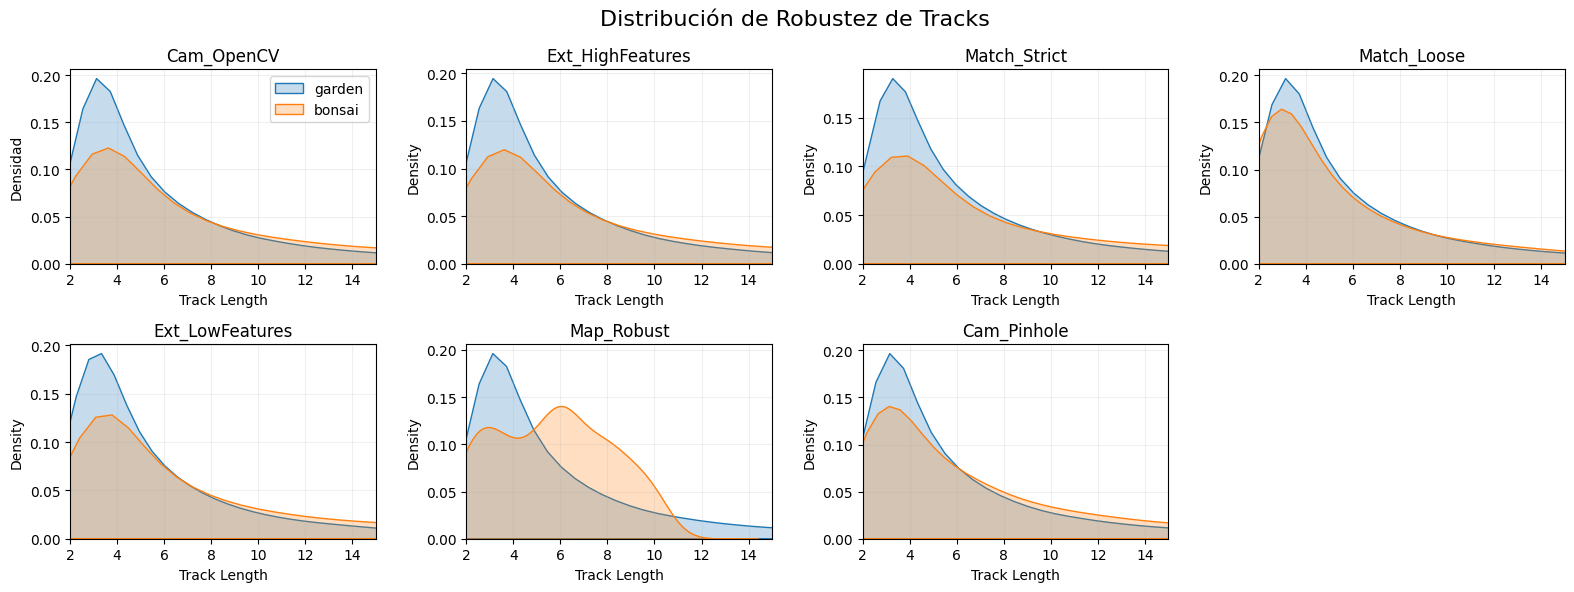

In [ ]:
configs_focus = [
    'Cam_OpenCV',
    'Ext_HighFeatures',
    'Match_Strict',
    'Match_Loose',
    'Ext_LowFeatures',
    'Map_Robust',
    'Cam_Pinhole'
]

palette = {
    'garden': '#1f77b4',
    'bonsai': '#ff7f0e'
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, cfg in enumerate(configs_focus):

    df_cfg = df[df['config'] == cfg]

    for _, row in df_cfg.iterrows():

        reco = pycolmap.Reconstruction(row['sparse_path'])

        lengths = [
            p.track.length()
            for p in reco.points3D.values()
        ]

        sns.kdeplot(
            lengths,
            ax=axes[i],
            fill=True,
            label=row['scene'],
            color=palette[row['scene']],
            bw_adjust=1.4
        )

    axes[i].set_title(cfg)
    axes[i].set_xlim(2, 15)
    axes[i].set_xlabel('Track Length')
    axes[i].grid(alpha=0.2)

axes[7].set_visible(False)

axes[0].set_ylabel('Densidad')
axes[0].legend()

plt.suptitle('Distribución de Robustez de Tracks', fontsize=16)
plt.tight_layout()
plt.show()


En `garden`, las distribuciones se mantienen relativamente similares entre configuraciones. La forma general de las curvas cambia poco al variar la configuración. Esto coincide con lo observado en las métricas anteriores: la escena outdoor presenta un comportamiento estable y robusto frente a variaciones del pipeline.

En `bonsai`, en cambio, aparecen diferencias mucho más marcadas entre configuraciones. El caso más evidente es `Map_Robust`, cuya distribución se desplaza hacia tracks más largos y presenta una forma completamente distinta al resto. Esto ocurre porque la reconstrucción colapsa parcialmente y sobrevive solo un subconjunto pequeño de puntos muy consistentes geométricamente, generando artificialmente tracks más largos.

Además, `Match_Loose` muestra una curva considerablemente más alta en tracks cortos. Esto indica que la configuración genera una gran cantidad de correspondencias débiles o poco consistentes, que son observadas por pocas imágenes y producen tracks menos robustos. Este comportamiento coincide con el aumento observado previamente en el error de reproyección y la reducción del `avg_track_length`.

Estas diferencias sugieren que la escena indoor es mucho más sensible a la calidad del matching y de la calibración geométrica. Factores como:
- menor baseline efectivo entre imágenes,
- presencia de texturas repetitivas,
- oclusiones frecuentes,
- profundidad de escena más reducida,
- iluminación indoor menos uniforme,

hacen que pequeñas variaciones del pipeline afecten rápidamente la estabilidad de las correspondencias multivista.

Por el contrario, la mayor cobertura espacial y redundancia visual de `garden` permiten mantener distribuciones de tracks relativamente estables incluso bajo configuraciones menos favorables.

## Factores que explican el comportamiento distinto del pipeline

### 1. Textura y distribución de features

La escena outdoor (`garden`) corresponde a un jardín con vegetación densa, fondo complejo y estructuras distribuidas a distintas profundidades. Esto genera muchas features discriminativas en hojas, ramas, tierra y objetos del entorno, produciendo gran cantidad de correspondencias válidas entre imágenes.

Como se observó en las secciones anteriores, `garden` mantiene una reconstrucción estable incluso con configuraciones más simples como `Ext_LowFeatures`, mostrando poca sensibilidad a cambios en extracción o matching.

En cambio, `bonsai` es una escena indoor centrada en un pequeño árbol sobre una mesa, con superficies lisas (pared, mesa) y textura concentrada en el follaje y las ramas. Las features se concentran principalmente en el bonsái y en detalles cercanos, por lo que errores pequeños en matching o calibración afectan mucho más la reconstrucción.

### 2. Profundidad de campo y modelo de cámara

La escena `garden` posee una gran variación de profundidad, incluyendo objetos cercanos y fondos lejanos. Debido a estas distancias mayores, pequeños errores en la calibración de cámara tienen menos impacto geométrico. Esto explica que `Cam_Pinhole` y `Cam_OpenCV` produzcan resultados similares en la escena outdoor.

En `bonsai`, la captura corresponde a fotogrametría de corto alcance (`close-range photogrammetry`). En este caso, la distorsión del lente y la calibración son mucho más importantes, ya que los objetos están cerca de la cámara y ocupan gran parte de la imagen. Por eso, `Cam_Pinhole` aumenta el error de reproyección y reduce el `track length`.

### 3. Baseline de cámara y paralaje

En `bonsai`, la cámara sigue una trayectoria 360° alrededor de un objeto pequeño. Esto hace que muchos puntos sean observados desde varias imágenes, generando tracks largos, pero con poco paralaje entre vistas consecutivas.

Por esta razón, configuraciones más estrictas como `Map_Robust` pueden hacer colapsar la reconstrucción, ya que el mapper necesita correspondencias geométricamente muy consistentes para inicializar el modelo.

En `garden`, la escena cubre un espacio mucho más amplio y con mayor variación espacial. Esto genera un paralaje más robusto y una geometría más estable, haciendo que la reconstrucción sea menos sensible a restricciones fuertes del mapper.

### 4. Iluminación y oclusiones

Aunque el dataset fue capturado con iluminación relativamente controlada y exposición fija, las escenas indoor siguen presentando más oclusiones y cambios locales de iluminación debido a objetos cercanos y geometría compacta.

En `bonsai`, las ramas, hojas y detalles pequeños producen auto-oclusiones frecuentes que dificultan encontrar correspondencias estables entre imágenes.

En `garden`, las texturas están distribuidas en toda la escena y la iluminación exterior es más uniforme sobre superficies amplias. Por eso, incluso configuraciones simples como `Ext_LowFeatures` logran reconstrucciones completas y relativamente estables.

Estas características visuales fueron documentadas en el Experimento A a partir del análisis del dataset original, donde se reporta que las escenas outdoor fueron capturadas con cielo nublado para obtener sombras suaves, y las indoor con grandes fuentes de luz difusa, minimizando variaciones fotométricas entre imágenes.

# Bibliografía

COLMAP Contributors. (2026a). *Feature extraction and matching*. COLMAP Documentation. https://colmap.github.io/tutorial.html

COLMAP Contributors. (2026b). *Reconstruction — mapper configuration*. COLMAP Documentation. https://colmap.github.io/tutorial.html

COLMAP Contributors. (2026c). *Camera models*. COLMAP Documentation. https://colmap.github.io/cameras.html

Juarez-Salazar, R., Zheng, J., & Díaz-Ramírez, V. H. (2020). Distorted pinhole camera modeling and calibration. *Applied Optics*, *59*(36), 11310–11318. https://doi.org/10.1364/ao.412159

Liu, S., Gao, Y., Zhang, T., Pautrat, R., Schönberger, J. L., Larsson, V., & Pollefeys, M. (2024). Robust incremental structure-from-motion with hybrid features. En A. Leonardis et al. (Eds.), *Computer Vision – ECCV 2024* (Lecture Notes in Computer Science, vol. 15094, pp. 249–269). Springer. https://doi.org/10.1007/978-3-031-72764-1_15

Mwtarnowski, P. (2021). *colmap-parameters* [Repositorio de GitHub]. https://github.com/mwtarnowski/colmap-parameters

Ramalingam, S., Lodha, S. K., & Sturm, P. (2006). A generic structure-from-motion framework. *Computer Vision and Image Understanding*, *103*(3), 218–228. https://doi.org/10.1016/j.cviu.2006.06.006

Schönberger, J. L., & Frahm, J.-M. (2016). Structure-from-motion revisited. En *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)* (pp. 4104–4113). https://doi.org/10.1109/CVPR.2016.445

Wang, Y., Yuan, Y., & Lei, Z. (2020). Fast SIFT feature matching algorithm based on geometric transformation. *IEEE Access*, *8*, 88133–88140. https://doi.org/10.1109/ACCESS.2020.2989157